# Proyek Klasifikasi Gambar: Fashion-MNIST

- **Nama:** Muslichin
- **Email:** muslichin.ach@gmail.com
- **ID Dicoding:** muslchn

Notebook ini membangun model klasifikasi gambar pakaian dari dataset open-source Fashion-MNIST. Dataset tidak dibuat sendiri dari Python; data bersumber dari Zalando Research dan diunduh melalui `tf.keras.datasets.fashion_mnist`.


## Import Semua Packages/Library yang Digunakan


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from submission import (
    CLASS_NAMES,
    DATASET_DIR,
    DATASET_NAME,
    DATASET_SOURCE,
    EPOCHS,
    SPLIT_DIR,
    SUBMISSION_DIR,
    build_model,
    export_models,
    generate_dataset,
    load_datasets,
    plot_history,
    print_images_resolution,
    run_tflite_inference,
    set_seed,
    split_dataset,
)

set_seed()
print(tf.__version__)
print(DATASET_NAME)
print(DATASET_SOURCE)


2.16.1
Fashion-MNIST
https://github.com/zalandoresearch/fashion-mnist


Matplotlib created a temporary cache directory at /tmp/matplotlib-g08y57y3 because the default path (/home/muss/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Data Preparation

### Data Loading

Dataset yang digunakan adalah Fashion-MNIST, dataset open-source berisi 70.000 gambar grayscale 28x28 piksel. Dataset diunduh melalui API Keras, lalu disimpan ulang sebagai gambar PNG dalam folder kelas agar proses klasifikasi gambar terlihat eksplisit dari file gambar.


In [2]:
generate_dataset()
print_images_resolution(DATASET_DIR)


Fashion-MNIST dataset already exists: 70000 images
ankle_boot: 7000
- (28, 28)
---------------
bag: 7000
- (28, 28)
---------------
coat: 7000
- (28, 28)
---------------
dress: 7000
- (28, 28)
---------------
pullover: 7000
- (28, 28)
---------------
sandal: 7000
- (28, 28)
---------------
shirt: 7000
- (28, 28)
---------------
sneaker: 7000
- (28, 28)
---------------
t-shirt_top: 7000
- (28, 28)
---------------
trouser: 7000
- (28, 28)
---------------

Total: 70000


### Data Preprocessing

Dataset dibagi menjadi train, validation, dan test set. Data training dan validation berasal dari official training split Fashion-MNIST, sedangkan test set berasal dari official test split.


In [3]:
split_dataset()
train_ds, validation_ds, test_ds = load_datasets()
print(train_ds)
print(validation_ds)
print(test_ds)
print(CLASS_NAMES)


Split dataset already exists: 70000 images
Found 48000 files belonging to 10 classes.
Found 12000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
['t-shirt_top', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle_boot']


## Modelling

Model menggunakan `Sequential`, beberapa layer `Conv2D`, `MaxPooling2D`, `Dropout`, `Flatten`, dan `Dense`. Callback digunakan untuk menyimpan model terbaik, menghentikan training saat performa validasi tidak membaik, dan menurunkan learning rate saat loss validasi stagnan.


In [4]:
model = build_model(num_classes=len(CLASS_NAMES))
model.summary()


Model: "fashion_mnist_training_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fashion_mnist_inference_cnn     │ (None, 10)             │       241,546 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 241,546 (943.54 KB)
 Trainable params: 241,546 (943.54 KB)
 Non-trainable params: 0 (0.00 B)


In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(SUBMISSION_DIR / "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/10
375/375 - 19s - 52ms/step - accuracy: 0.7592 - loss: 0.6578 - val_accuracy: 0.8646 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 2/10
375/375 - 14s - 36ms/step - accuracy: 0.8594 - loss: 0.3866 - val_accuracy: 0.8813 - val_loss: 0.3103 - learning_rate: 0.0010
Epoch 3/10
375/375 - 13s - 35ms/step - accuracy: 0.8775 - loss: 0.3347 - val_accuracy: 0.8924 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 4/10
375/375 - 13s - 36ms/step - accuracy: 0.8918 - loss: 0.2971 - val_accuracy: 0.9091 - val_loss: 0.2452 - learning_rate: 0.0010
Epoch 5/10
375/375 - 13s - 35ms/step - accuracy: 0.8997 - loss: 0.2759 - val_accuracy: 0.9064 - val_loss: 0.2525 - learning_rate: 0.0010
Epoch 6/10
375/375 - 17s - 45ms/step - accuracy: 0.9072 - loss: 0.2554 - val_accuracy: 0.9158 - val_loss: 0.2268 - learning_rate: 0.0010
Epoch 7/10
375/375 - 16s - 44ms/step - accuracy: 0.9133 - loss: 0.2370 - val_accuracy: 0.9153 - val_loss: 0.2233 - learning_rate: 0.0010
Epoch 8/10
375/375 - 19s - 50ms/step - ac

## Evaluasi dan Visualisasi


Training accuracy: 0.9374
Testing accuracy: 0.9140
Training loss: 0.1737
Testing loss: 0.2338


/home/muss/codes/dicoding/klasifikasi-gambar/submission.py:221: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


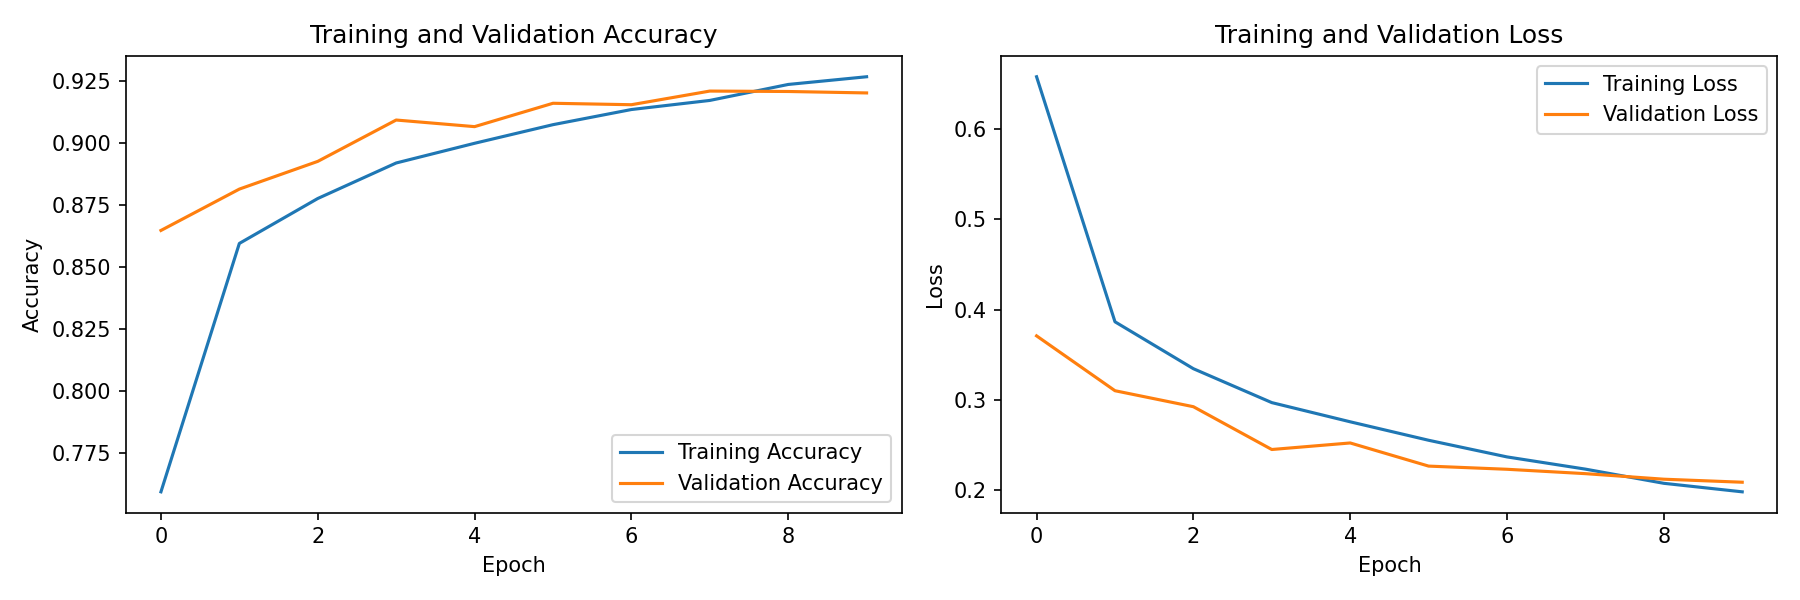

In [6]:
plot_history(history)

train_loss, train_accuracy = model.evaluate(train_ds, verbose=0)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Testing accuracy: {test_accuracy:.4f}")
print(f"Training loss: {train_loss:.4f}")
print(f"Testing loss: {test_loss:.4f}")


## Konversi Model

Model disimpan ke format SavedModel, TensorFlow Lite, dan TensorFlow.js.


In [7]:
export_models(model)


Saved artifact at '/home/muss/codes/dicoding/klasifikasi-gambar/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  131718381245488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381243552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381246016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381246896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381245664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381247600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381246720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381247776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381248304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131718381249184: TensorSpec(shape=(), dtype=t

## Inference

Inference dilakukan menggunakan model TensorFlow Lite yang sudah dikonversi.


In [8]:
run_tflite_inference()


Sample image: /home/muss/codes/dicoding/klasifikasi-gambar/dataset_split/fashion_mnist/test/t-shirt_top/original_test_00019.png
True label: t-shirt_top
Predicted label: t-shirt_top
Confidence: 0.9797
All probabilities: {'t-shirt_top': 0.9797000288963318, 'trouser': 0.0, 'pullover': 0.0010999999940395355, 'dress': 0.0020000000949949026, 'coat': 0.0, 'sandal': 0.0, 'shirt': 0.017100000753998756, 'sneaker': 0.0, 'bag': 9.999999747378752e-05, 'ankle_boot': 0.0}
